Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size    

C:\Users\Dell\AppData\Local\Temp\ipykernel_20180\2467143425.py:69: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Date')['Weekly_Sales'].sum()


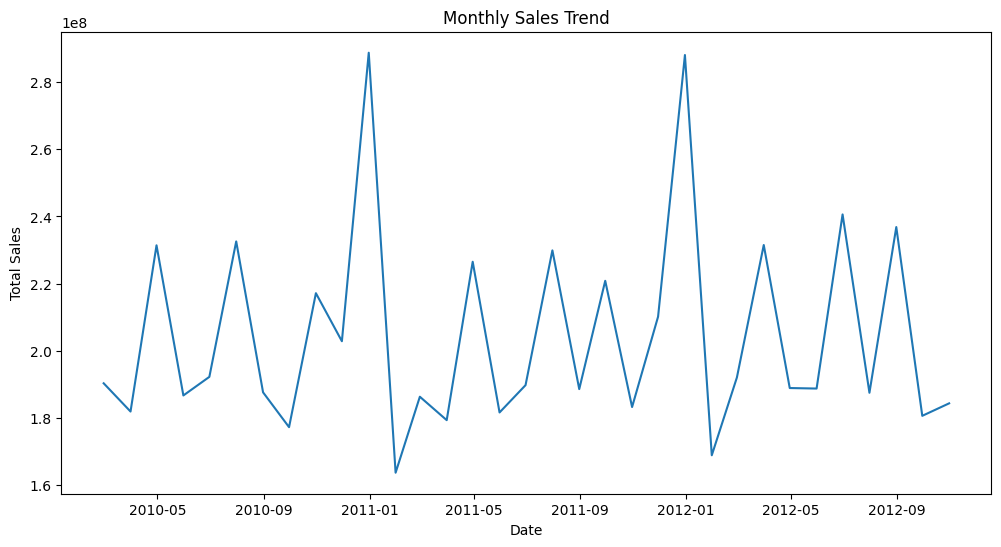

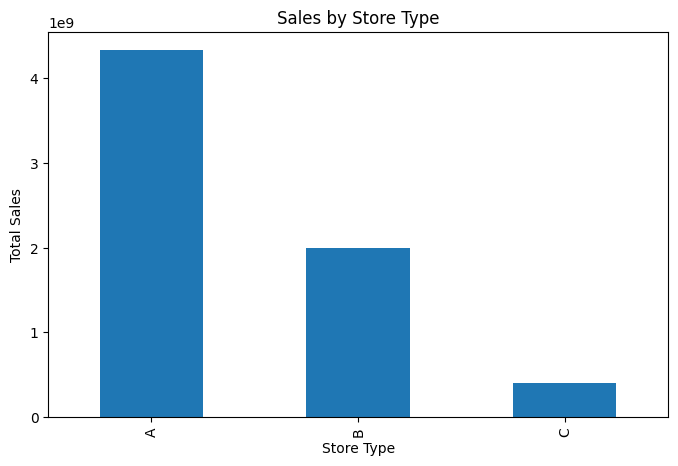

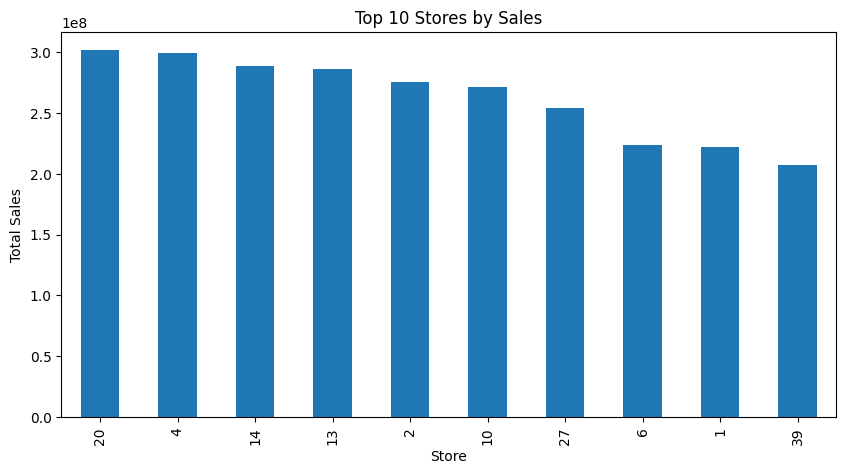

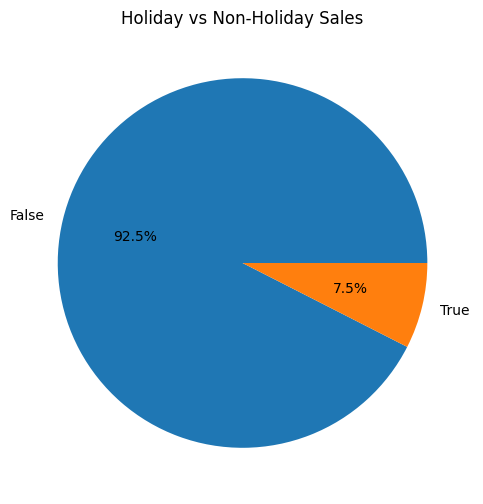

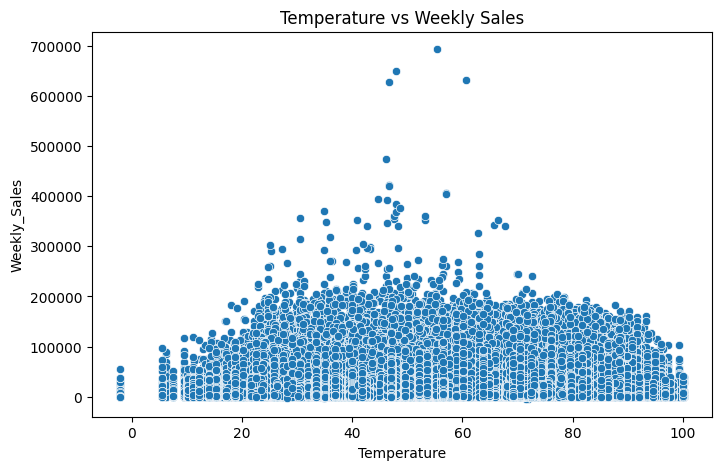

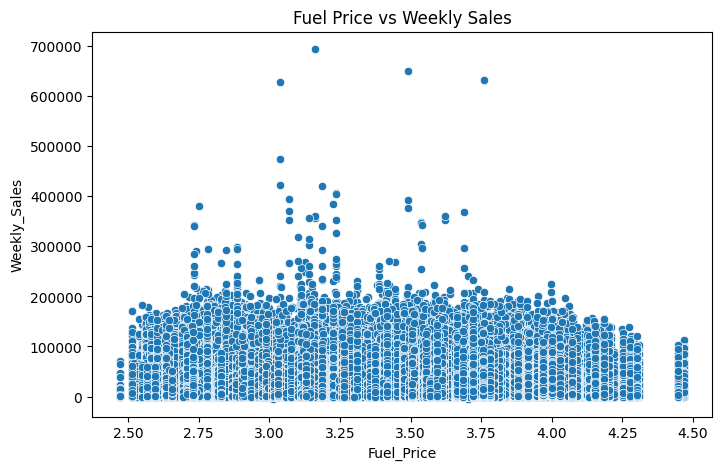

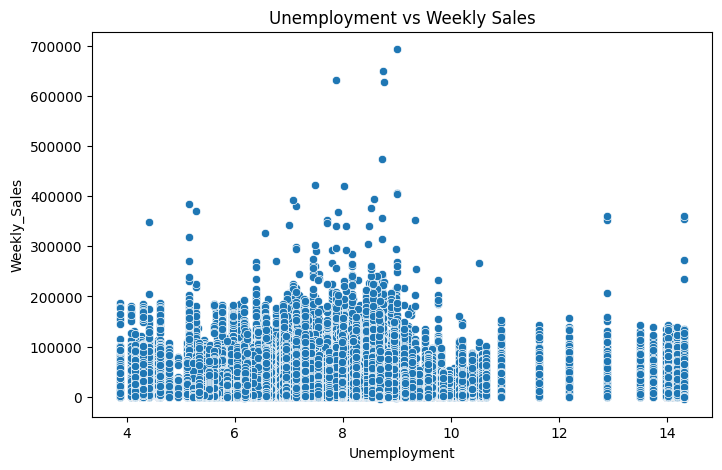

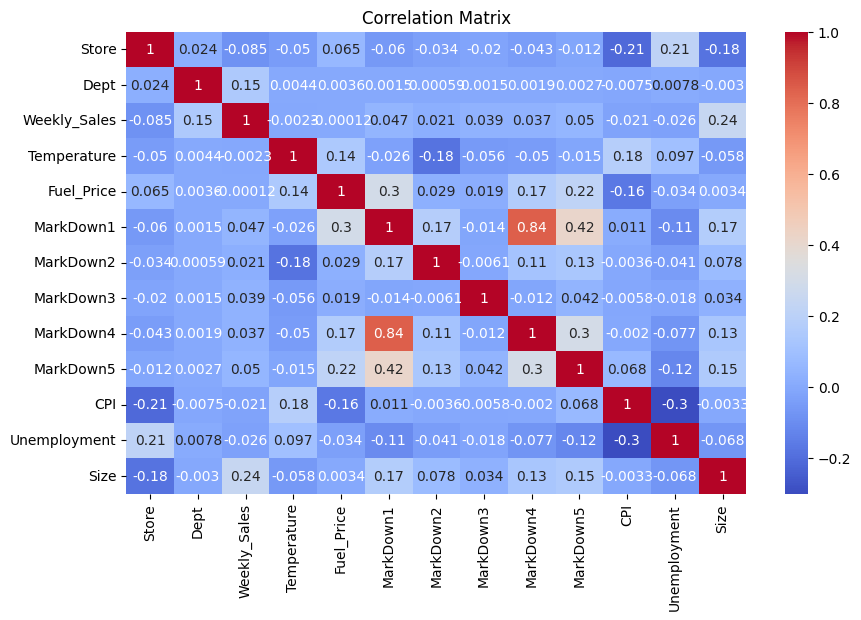

C:\Users\Dell\AppData\Local\Temp\ipykernel_20180\2467143425.py:149: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Date')['Weekly_Sales'].sum()
C:\Users\Dell\miniforge3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


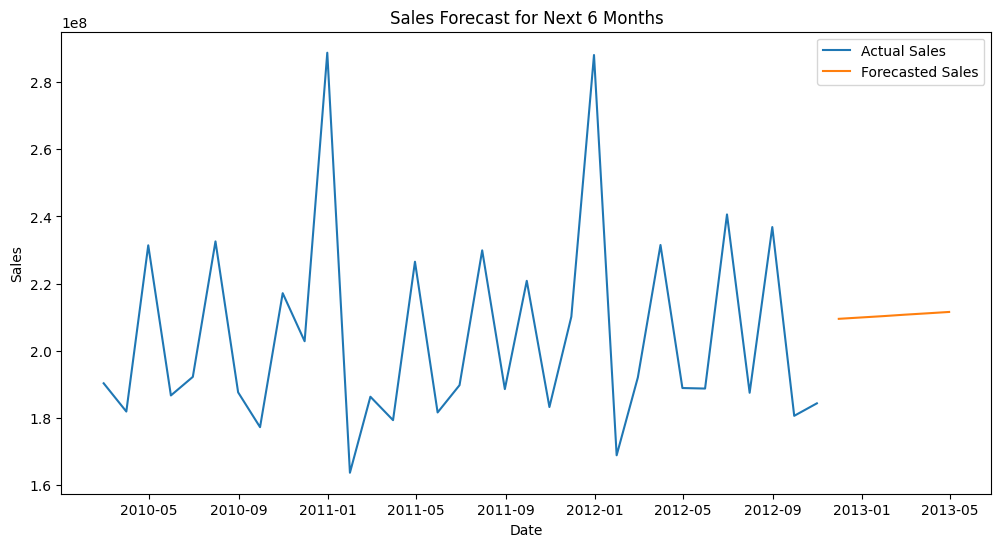

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
df = pd.read_csv(r"C:\Users\Dell\OneDrive\Desktop\Sales trend and revenue forecasting\cleaned_walmart_sales_v2.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')if 'IsHoliday_x' in df.columns:
    df.rename(columns={'IsHoliday_x': 'IsHoliday'}, inplace=True)
if 'IsHoliday_y' in df.columns:
    df.drop(columns=['IsHoliday_y'], inplace=True)
df.fillna(0, inplace=True)
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
total_revenue = df['Weekly_Sales'].sum()
avg_weekly_sales = df['Weekly_Sales'].mean()
total_stores = df['Store'].nunique()
total_departments = df['Dept'].nunique()
holiday_revenue = df[df['IsHoliday'] == True]['Weekly_Sales'].sum()
non_holiday_revenue = df[df['IsHoliday'] == False]['Weekly_Sales'].sum()
print("\n--- KPI SUMMARY ---")
print("Total Revenue:", total_revenue)
print("Average Weekly Sales:", avg_weekly_sales)
print("Total Stores:", total_stores)
print("Total Departments:", total_departments)
print("Holiday Revenue:", holiday_revenue)
print("Non-Holiday Revenue:", non_holiday_revenue)
monthly_sales = df.resample('M', on='Date')['Weekly_Sales'].sum()
plt.figure(figsize=(12,6))
plt.plot(monthly_sales)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()
store_type_sales = df.groupby('Type')['Weekly_Sales'].sum()
plt.figure(figsize=(8,5))
store_type_sales.plot(kind='bar')
plt.title("Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Total Sales")
plt.show()
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
store_sales.plot(kind='bar')
plt.title("Top 10 Stores by Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].sum()
plt.figure(figsize=(6,6))
holiday_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Holiday vs Non-Holiday Sales")
plt.ylabel("")
plt.show()
plt.figure(figsize=(8,5))
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df)
plt.title("Temperature vs Weekly Sales")
plt.show()
plt.figure(figsize=(8,5))
sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=df)
plt.title("Fuel Price vs Weekly Sales")
plt.show()
plt.figure(figsize=(8,5))
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=df)
plt.title("Unemployment vs Weekly Sales")
plt.show()
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
monthly_sales = df.resample('M', on='Date')['Weekly_Sales'].sum()
model = ExponentialSmoothing(
    monthly_sales,
    trend='add',
    seasonal=None
)
model_fit = model.fit()
forecast = model_fit.forecast(6)
plt.figure(figsize=(12,6))
plt.plot(monthly_sales, label='Actual Sales')
plt.plot(forecast, label='Forecasted Sales')
plt.title("Sales Forecast for Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()